<a href="https://colab.research.google.com/github/riyarani6180/LLM_Projects/blob/daily_classes/30may.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer=BertTokenizer.from_pretrained("bert-base-uncased")
model=BertModel.from_pretrained("bert-base-uncased")

input_text='''I am Rituparna and I am learning llm models now. I like to read about ml and ai related stuff as
it is highly fascinating. I aspire to work in this field and develop some tech which will help solve some of the worldly problems.
I am so grateful to be part of this program.'''

tokens=tokenizer(input_text, return_tensors="pt")

with torch.no_grad():
  outputs=model(**tokens) #Generating token embeddings

last_hidden_states=outputs.last_hidden_state

print("Token embeddings:")

for token, embedding in zip(tokens["input_ids"][0], last_hidden_states[0]):
  word=tokenizer.decode(int(token))
  print(f"{word}: {embedding}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Streaming output truncated to the last 5000 lines.
        -2.8403e-01,  3.9674e-01,  5.5882e-01,  2.3268e-01,  5.4261e-01,
        -1.9001e-01,  4.4923e-01, -2.5304e-01,  3.7526e-01, -7.8804e-01,
         4.5069e-01,  4.7904e-01, -1.7105e-01, -4.2817e-01,  1.6273e-01,
        -3.5066e-01,  3.2410e-01, -7.4248e-01,  4.5332e-01,  3.7001e-01,
        -4.2856e-02, -2.3995e-01, -7.6734e-01, -9.3155e-02,  6.6284e-01,
         6.7164e-01, -1.1445e+00, -3.3422e-01,  5.7281e-02,  4.5470e-01,
        -8.1597e-01,  9.1981e-01, -4.4289e-01,  8.6150e-02,  4.5561e-02,
        -5.9588e-01,  1.2489e-01,  4.7336e-01,  4.2694e-01,  9.3489e-01,
         7.0649e-02, -9.2702e-02, -5.4498e-01, -7.8601e-02,  4.3984e-01,
        -1.2813e-01,  5.1109e-02,  3.7026e-02, -1.6608e-02, -6.8996e-02,
        -4.7528e-01, -8.8071e-02, -2.6431e-01,  4.0839e-01,  8.5870e-01,
        -7.7863e-01,  8.6610e-01, -4.6496e-01,  2.9165e-01, -2.8054e-01,
        -3.7533e-01,  1.9294e-01, -2.1200e-01,  6.1705e-01, -5.6570e-01,


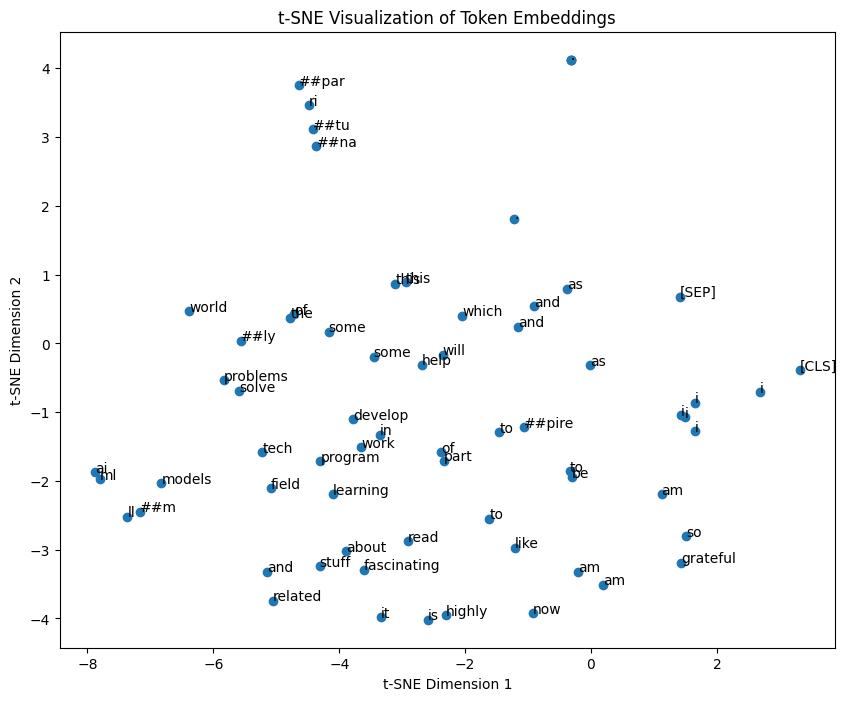

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne=TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_tsne=tsne.fit_transform(last_hidden_states[0])

plt.figure(figsize=(10,8))
plt.scatter(embeddings_tsne[:,0], embeddings_tsne[:,1], marker='o')
for i , word in enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])):
  plt.annotate(word, xy=(embeddings_tsne[i,0], embeddings_tsne[i,1]),fontsize=10)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Token Embeddings')
plt.show()